# Music Analysis

My goal is to make an automated system to break down recorded music into individual notes to aid in transcription.

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

Load in the data

In [2]:
with open("music_samples.txt", 'r') as file:
    lines = file.readlines()

signal = np.array([float(element) for element in lines])
frequency = 44100
duration = len(signal) / frequency
times = np.linspace(0, duration, len(lines))


Text(0, 0.5, 'Amplitude (volts?)')

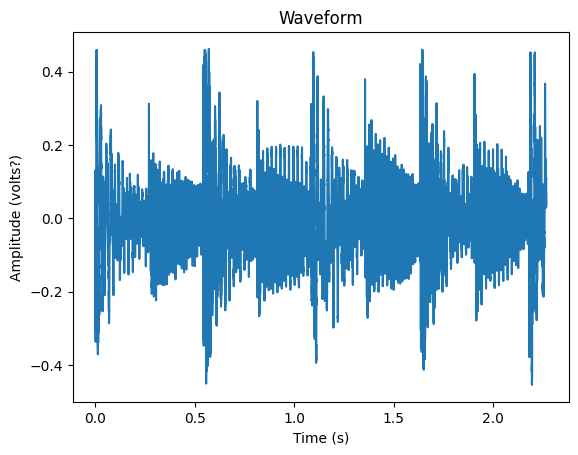

In [3]:
plt.plot(times, signal)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (volts?)")

Break the signal down into eight-note subsections

In [4]:
bpm = 110
bps = bpm / 60
n_beats = duration * bps
n_eights = n_beats * 2
seg_length = int(len(signal) / n_eights)
segs = len(signal) // seg_length

record_detune_cents = -15.6

In [5]:
def freq_to_note(freq):
    names = [
        "C", "C#", "D", "Eb", "E", "F", "F#", "G", "Ab", "A", "Bb", "B"
    ]
    A4 = 440.0
    C0 = A4 * (2 ** -4.75)

    h = np.round(12 * np.log2(freq / C0))
    octave = int(h // 12)
    note = int(h % 12)

    f_ref = C0 * (2 ** (h / 12))
    cents = 1200 * np.log2(freq / f_ref)

    return names[note] + str(octave), cents

In [6]:
all_notes = []
for i in range(segs):
    seg = signal[i*seg_length:(i+1)*seg_length]

    fourier = np.fft.fft(seg)
    fourier = np.abs(np.real(fourier))
    freqs = np.fft.fftfreq(seg.shape[-1]) * frequency

    # Limit to positive values
    fourier = fourier[:int(len(fourier)/2)]
    freqs = freqs[:int(len(freqs)/2)]

    # Limit to 5-octave range to eliminate weird stuff from percussion
    start = np.searchsorted(freqs, 55, "left")
    end = np.searchsorted(freqs, 1760, "right")
    fourier = fourier[start:end]
    freqs = freqs[start:end]

    peaks, properties = sp.signal.find_peaks(fourier, height=5, distance=6.7)
    peak_freqs = freqs[peaks]
    order = np.argsort(properties['peak_heights'])[::-1]
    peak_freqs = peak_freqs[order][:12]

    notes = [freq_to_note(freq) for freq in peak_freqs]
    errors = np.abs(np.array([note[1] - record_detune_cents for note in notes]))
    notes = np.array([note[0] for note in notes])
    order = np.argsort(errors)
    notes = notes[order]
    all_notes.append(tuple(notes[:6]))

In [7]:
print(np.array(all_notes))

[['F#3' 'Bb3' 'Eb3' 'C#5' 'C6' 'F4']
 ['F#2' 'F#3' 'C#4' 'C#5' 'C6' 'C#6']
 ['F#2' 'Bb3' 'C#5' 'F4' 'Ab5' 'C6']
 ['F#2' 'F#3' 'Bb3' 'C#4' 'F6' 'F#5']
 ['F#3' 'Eb3' 'C#4' 'C#5' 'Ab5' 'C#6']
 ['F#2' 'F#3' 'F#4' 'C#4' 'C#5' 'F6']
 ['F#3' 'F#2' 'F#4' 'C#6' 'C#5' 'C#3']
 ['F#2' 'F#3' 'Bb3' 'C#4' 'Eb6' 'F#5']]
